## Batch Normalization (BN)

### 1. Khái niệm
Batch Normalization là kỹ thuật chuẩn hóa activation trong từng mini-batch nhằm giữ cho phân phối dữ liệu ổn định trong quá trình huấn luyện.



### 2. Mục tiêu
- Không phải để các lớp có cùng phân phối với nhau  
- Mà để:
  > **Giữ cho input của mỗi layer luôn ổn định (mean ≈ 0, variance ≈ 1)**

→ Giúp mạng học nhanh và ổn định hơn



### 3. Quy trình hoạt động

Với input \(x\) trong một batch:

1. Tính mean và variance:
\[
\mu_B = \frac{1}{m} \sum x_i
\]
\[
\sigma_B^2 = \frac{1}{m} \sum (x_i - \mu_B)^2
\]

2. Chuẩn hóa:
\[
\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}
\]

3. Scale & Shift:
\[
y = \gamma \hat{x} + \beta
\]



### 4. Tham số học

BatchNorm chỉ học:
- **γ (gamma)**: scale
- **β (beta)**: shift

Không học:
- mean (μ)
- variance (σ²)



### 5. Cách học

- γ và β được cập nhật bằng **backpropagation**
- Giống như weight của Conv/Linear



### 6. Vai trò

- Conv/Linear:
  > Học feature (pattern)

- BatchNorm:
  > Chuẩn hóa và điều chỉnh phân phối của feature



### 7. Insight quan trọng

- Weight update → làm thay đổi distribution
- BatchNorm:
  > **Chuẩn hóa lại ngay trong mỗi forward pass**

→ Không cho distribution “trôi”



### 8. Vị trí trong mạng

Thường dùng:
Conv → BatchNorm → ReLU



### 9. Train vs Inference

**Train:**
- Dùng mean, variance của batch
- Cập nhật running statistics

**Inference:**
- Dùng running mean, variance
- Không phụ thuộc batch



### 10. Lợi ích

- Tăng tốc độ hội tụ
- Ổn định gradient
- Cho phép learning rate lớn hơn
- Giảm overfitting nhẹ



### 11. Hạn chế

- Phụ thuộc batch size
- Kém hiệu quả khi batch nhỏ
- Không phù hợp với RNN



### 12. Tóm tắt

> **BatchNorm = chuẩn hóa mỗi batch + học scale (γ) và shift (β)**  
> → giúp mạng học nhanh, ổn định và hiệu quả hơn

In [1]:
import torch
from torch import nn

def batch_norm(X, gamma, beta, moving_mean, moving_var, eps, momentum):
    # Use is_grad_enabled to determine whether we are in training mode
    if not torch.is_grad_enabled():
        # In prediction mode, use mean and variance obtained by moving average
        X_hat = (X - moving_mean) / torch.sqrt(moving_var + eps)
    else:
        assert len(X.shape) in (2, 4)
        if len(X.shape) == 2:
            # When using a fully connected layer, calculate the mean and
            # variance on the feature dimension
            mean = X.mean(dim=0)
            var = ((X - mean) ** 2).mean(dim=0)
        else:
            # When using a two-dimensional convolutional layer, calculate the
            # mean and variance on the channel dimension (axis=1). Here we
            # need to maintain the shape of X, so that the broadcasting
            # operation can be carried out later
            mean = X.mean(dim=(0, 2, 3), keepdim=True)
            var = ((X - mean) ** 2).mean(dim=(0, 2, 3), keepdim=True)
        # In training mode, the current mean and variance are used
        X_hat = (X - mean) / torch.sqrt(var + eps)
        # Update the mean and variance using moving average
        moving_mean = (1.0 - momentum) * moving_mean + momentum * mean
        moving_var = (1.0 - momentum) * moving_var + momentum * var
    Y = gamma * X_hat + beta  # Scale and shift
    return Y, moving_mean.data, moving_var.data

In [ ]:
class BatchNorm(nn.Module):
    # num_features: the number of outputs for a fully connected layer or the
    # number of output channels for a convolutional layer. num_dims: 2 for a
    # fully connected layer and 4 for a convolutional layer
    def __init__(self, num_features, num_dims):
        super().__init__()
        if num_dims == 2:
            shape = (1, num_features)
        else:
            shape = (1, num_features, 1, 1)
        # The scale parameter and the shift parameter (model parameters) are
        # initialized to 1 and 0, respectively
        self.gamma = nn.Parameter(torch.ones(shape))
        self.beta = nn.Parameter(torch.zeros(shape))
        # The variables that are not model parameters are initialized to 0 and
        # 1
        self.moving_mean = torch.zeros(shape)
        self.moving_var = torch.ones(shape)

    def forward(self, X):
        # If X is not on the main memory, copy moving_mean and moving_var to
        # the device where X is located
        if self.moving_mean.device != X.device:
            self.moving_mean = self.moving_mean.to(X.device)
            self.moving_var = self.moving_var.to(X.device)
        # Save the updated moving_mean and moving_var
        Y, self.moving_mean, self.moving_var = batch_norm(
            X, self.gamma, self.beta, self.moving_mean,
            self.moving_var, eps=1e-5, momentum=0.1)
        return Y

In [4]:
class BNLeNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5), nn.LazyBatchNorm2d(),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), nn.LazyBatchNorm2d(),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Flatten(), nn.LazyLinear(120), nn.LazyBatchNorm1d(),
            nn.Sigmoid(), nn.LazyLinear(84), nn.LazyBatchNorm1d(),
            nn.Sigmoid(), nn.LazyLinear(num_classes))
        
    def layer_summary(self, X_shape):
        X = torch.randn(X_shape)
        for layer in self.net:
            X = layer(X)
            print(layer.__class__.__name__, 'output shape:\t', X.shape)

    def forward(self, X):
        return self.net(X)

In [5]:
model = BNLeNet(10)
model.layer_summary((128, 1, 28, 28))

Conv2d output shape:	 torch.Size([128, 6, 24, 24])
BatchNorm2d output shape:	 torch.Size([128, 6, 24, 24])
Sigmoid output shape:	 torch.Size([128, 6, 24, 24])
AvgPool2d output shape:	 torch.Size([128, 6, 12, 12])
Conv2d output shape:	 torch.Size([128, 16, 8, 8])
BatchNorm2d output shape:	 torch.Size([128, 16, 8, 8])
Sigmoid output shape:	 torch.Size([128, 16, 8, 8])
AvgPool2d output shape:	 torch.Size([128, 16, 4, 4])
Flatten output shape:	 torch.Size([128, 256])
Linear output shape:	 torch.Size([128, 120])
BatchNorm1d output shape:	 torch.Size([128, 120])
Sigmoid output shape:	 torch.Size([128, 120])
Linear output shape:	 torch.Size([128, 84])
BatchNorm1d output shape:	 torch.Size([128, 84])
Sigmoid output shape:	 torch.Size([128, 84])
Linear output shape:	 torch.Size([128, 10])


In [6]:
import torchvision
from torchvision import transforms

trans = torchvision.transforms.Compose([transforms.Resize((32, 32)), transforms.ToTensor()])

data_train = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=trans,
    download=True)
data_val = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=trans,
    download=True
)

len(data_train), len(data_val)

100%|██████████| 9.91M/9.91M [00:00<00:00, 22.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 603kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.54MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.43MB/s]


(60000, 10000)

In [7]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    data_train,
    batch_size=128,
    shuffle=True
)

val_loader = DataLoader(
    data_val,
    batch_size=128,
    shuffle=False
)

In [8]:
from torch import optim

model = BNLeNet(10)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(params=model.parameters(), lr=0.01)

epochs = 20

loss_histoty = {"train": [], "val": []}

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        y_hat = model(X_batch)

        loss = criterion(y_hat, y_batch)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_loss += loss.item()
    train_loss_avg = train_loss / len(train_loader)
    loss_histoty["train"].append(train_loss_avg)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            y_hat = model(X_batch)
            loss = criterion(y_hat, y_batch)
            val_loss += loss.item()
        
        val_loss_avg = val_loss / len(val_loader)
        loss_histoty["val"].append(val_loss_avg)
    print(f"Epoch {epoch+1}/{epochs}: Train Loss: {train_loss_avg}, Val Loss: {val_loss_avg}")





Epoch 1/20: Train Loss: 1.582068522601748, Val Loss: 1.1954480945309507
Epoch 2/20: Train Loss: 0.9924031474442878, Val Loss: 0.7781154486951949
Epoch 3/20: Train Loss: 0.6649713106373988, Val Loss: 0.5417695000201841
Epoch 4/20: Train Loss: 0.4716367491526898, Val Loss: 0.3844446634189992
Epoch 5/20: Train Loss: 0.35829217881282, Val Loss: 0.298788363043266
Epoch 6/20: Train Loss: 0.2880771751088628, Val Loss: 0.242924545667594
Epoch 7/20: Train Loss: 0.23996513205042272, Val Loss: 0.21226938125453418
Epoch 8/20: Train Loss: 0.206087318882505, Val Loss: 0.180881468697062
Epoch 9/20: Train Loss: 0.18089266934755768, Val Loss: 0.15893739070507545
Epoch 10/20: Train Loss: 0.16134098223023324, Val Loss: 0.14565275005901915
Epoch 11/20: Train Loss: 0.14538169939761986, Val Loss: 0.1317113985932326
Epoch 12/20: Train Loss: 0.13322178682665836, Val Loss: 0.121853529180907
Epoch 13/20: Train Loss: 0.1225503130333383, Val Loss: 0.108330119236172
Epoch 14/20: Train Loss: 0.11387003103553105, Va

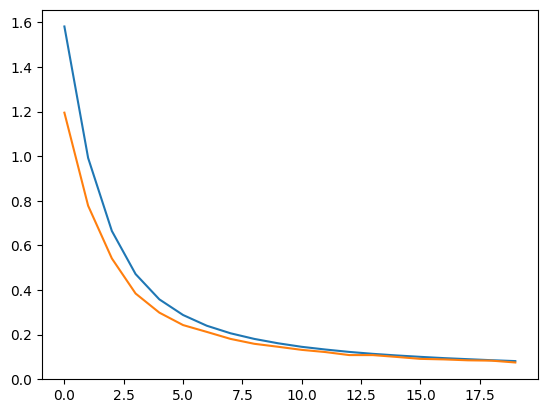

In [9]:
from matplotlib import pyplot as plt

plt.plot(loss_histoty["train"], label="train_loss")
plt.plot(loss_histoty["val"], label = "val_loss")

plt.show()

In [10]:
from sklearn.metrics import classification_report

# Tính toán predictions trên tất cả validation data
y_true = []
y_pred = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        
        y_hat = model.forward(X_batch)
        predictions = y_hat.argmax(dim=1)
        
        y_true.extend(y_batch)
        y_pred.extend(predictions)

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       1.00      0.99      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.98      0.99      0.99      1010
           4       0.99      0.98      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.98      0.98      1028
           8       0.99      0.98      0.99       974
           9       0.97      0.99      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

